In [ ]:
import tensorflow as tf


In [ ]:
a=tf.constant(2)

In [ ]:
b=tf.constant(a)

In [ ]:
c=tf.Variable(3)

In [ ]:
e=5
d=tf.Variable(e)

In [ ]:
result1=a+b

In [ ]:
print(a+c)

tf.Tensor(5, shape=(), dtype=int32)


In [ ]:
c.assign(8)

<tf.Variable 'UnreadVariable' shape=() dtype=int32, numpy=8>

In [ ]:
result2=(a+c)

In [ ]:
print(result2)

tf.Tensor(10, shape=(), dtype=int32)


In [ ]:
a=tf.constant(2)



In [ ]:
a.shape

TensorShape([])

In [ ]:
a.dtype

tf.int32

In [ ]:
a.ndim

0

In [ ]:
b=tf.constant([1,2,3])

In [ ]:
print(b)

tf.Tensor([1 2 3], shape=(3,), dtype=int32)


In [ ]:
b.shape

TensorShape([3])

In [ ]:
c=tf.constant([[1,2],[2,3]])

In [ ]:
print(c)

tf.Tensor(
[[1 2]
 [2 3]], shape=(2, 2), dtype=int32)


In [ ]:
tf.ones([2,2])

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[1., 1.],
       [1., 1.]], dtype=float32)>

In [ ]:
tf.zeros([2,2])

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[0., 0.],
       [0., 0.]], dtype=float32)>

Date :- 22/01/26


In [ ]:
#broadcasting
import tensorflow as tf

a = tf.constant([[2,3,4],[4,5,6]])
b = tf.constant([[2,4,3]])

In [ ]:
c=tf.add(a,b)

In [ ]:
print(c)

tf.Tensor(
[[4 7 7]
 [6 9 9]], shape=(2, 3), dtype=int32)


In [ ]:
c.numpy()

array([[4, 7, 7],
       [6, 9, 9]], dtype=int32)

In [ ]:
#slicing and indexing
a=tf.constant([[2,3,4],[4,5,6],[3,7,9]])

In [ ]:
a.ndim

2

In [ ]:
a= tf.constant([[2,3,4],[3,8,9]])

In [ ]:
b = tf.squeeze(a)

In [ ]:
b.numpy()

array([[2, 3, 4],
       [3, 8, 9]], dtype=int32)

In [ ]:
b.ndim

2

28-01-26

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
x=tf.constant([200,420,380,540,600,780])
y=tf.constant([20,10,30,400,500,600])


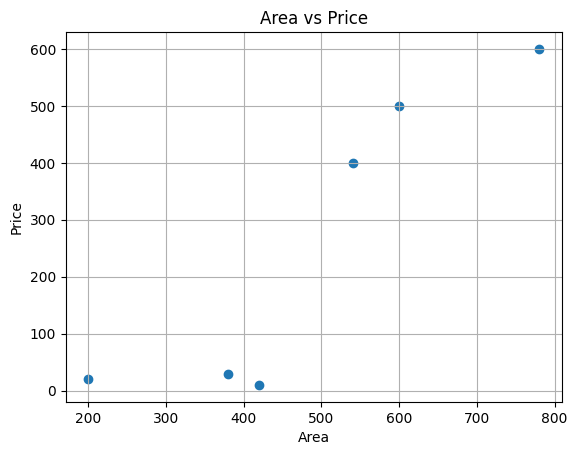

In [ ]:
#visulatoion
plt.scatter(x, y)
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.grid(True)
plt.show()

In [ ]:
#Create a modle to calculate the output:
m=tf.Variable(0.0)
b=tf.Variable(0.0)


learning_rate=0.001
epochs = 100
x_float=tf.cast(x,tf.float32)
y_float=tf.cast(y,tf.float32)
for i in range(epochs):
  with tf.GradientTape() as tape:
    pred = m * x_float + b
    loss = tf.reduce_mean((y_float-pred)**2)

  grads = tape.gradient(loss,[m,b])
  m.assign_sub(learning_rate*grads[0])
  b.assign_sub(learning_rate*grads[1])
  if i%20==0:
    print(f"[Eager]Step{i}:Loss{loss.numpy():.4f}")

[Eager]Step0:Loss128566.6641
[Eager]Step20:Lossnan
[Eager]Step40:Lossnan
[Eager]Step60:Lossnan
[Eager]Step80:Lossnan


AttributeError: PathCollection.set() got an unexpected keyword argument 'lable'

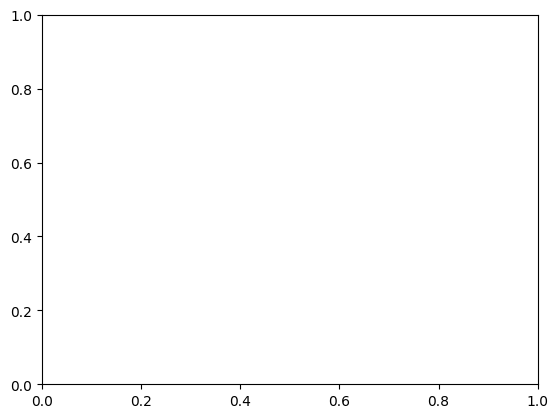

In [ ]:
from matplotlib.lines import lineStyles
plt.scatter(x_float,y_float,lable="True Prices")
plt.plot(x_float,m*x_float+b,lable="Eager line", color="blue",linestyle="--")
plt.plot(x_float,m_graph*x_float+b_graph,lable="Graph line",color="green")
plt.xlable("Income")
plt.ylable("Price")
plt.legend()
plt.grid(True)
plt.show()

02/02/2026


In [ ]:
import numpy as np
np.random.seed(42)
X = np.array([[0.5,0.1],
             [0.9,0.8]])
Y = np.array([[1],
             [0]])



In [ ]:
W1 = np.random.randn(2,2)
b1 = np.zeros((1,2))
W2 = np.random.randn(2,1)
b2 = np.zeros((1,1))

In [ ]:
def relu(z):
  return np.maximum(0,z)
def relu_derivative(z):
  return(z>0).astype(float)
def sigmoid (z):
  return 1/ (1+np.exp(-z))
def sigmoid_derivative(a):
  return a*(1-a)

In [ ]:
learning_rate = 0.1
epochs = 1000
for epoch in range(epochs):
  z1 = np.dot(X,W1) + b1
  A1 = relu(z1)
  z2 = np.dot(A1,W2) + b2
  A2 = sigmoid(z2)

  loss = -np.mean(Y*np.log(A2+ 1e-8)+(1-Y)*np.log(1-A2+1e-8))
  dZ2 = A2 - Y
  dW2 = np.dot(A1.T,dZ2)
  db2 = np.sum(dZ2,axis=0,keepdims=True)

  dA1 = np.dot(dZ2,W2.T)
  dZ1 = dA1 * relu_derivative(z1)
  dW1 = np.dot(X.T,dZ1)
  db1 = np.sum(dZ1,axis=0,keepdims=True)
  W2 -= learning_rate * dW2
  b2 -= learning_rate * db2
  W1 -= learning_rate * dW1
  b1 -= learning_rate * db1
  if epoch % 100 == 0:
    print(f"Epoch {epoch}: Loss {loss:.4f}")


Epoch 0: Loss 0.6338
Epoch 100: Loss 0.1029
Epoch 200: Loss 0.0447
Epoch 300: Loss 0.0273
Epoch 400: Loss 0.0194
Epoch 500: Loss 0.0150
Epoch 600: Loss 0.0122
Epoch 700: Loss 0.0102
Epoch 800: Loss 0.0088
Epoch 900: Loss 0.0077


05/02/2026


Sigmoid function

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

In [ ]:
X = np.array([[2.6,3.4,3.2],[1.7,1.4,1.7],[1.8,1.6,1.9],[2.4,2.1,2.6]])
y = np.array([[1],[0],[0],[1]])

In [ ]:
#defined activation function for implemenating.
def relu(x):
  return np.maximum(0,x)
def sigmoid(x):
  return 1/(1+np.exp(-x))
def softmax(x):
  return np.exp(x)/np
def relu_derivative(z):
  return (z>0).astype(float)

In [ ]:
#instializating weight and biases (for y=W*X +B)
np.random.seed(42)
w1 = np.random.randn(3,3)
b1 = np.zeros((1,3))
w2 = np.random.randn(3,1)
b2 = np.zeros((1,1))


In [ ]:
# intialising traning hyperparameters
learning_rate = 0.001
epochs = 1000 #for backpropagation

for epoch in range(epochs):
  Z1 = np.dot(X,w1) + b1
  A1 = relu(Z1)

  Z2 = np.dot(A1,w2) + b2
  A2 = sigmoid(Z2)

  loss = -np.mean(y*np.log(A2+1e-8)+(1-y)*np.log(1-A2+1e-8))
  dZ2 = A2 -y
  dw2 = np.dot(A1.T,dz2)
  db2 = np.sum(dz2,axis=0,keepdims=True)

  dA1 = np.dot(dZ2, w2.T)
  dZ1 = dA1 * relu_derivative(Z1)
  dw1 = np.dot(X.T,dZ1)
  db1 = np.sum(dZ1,axis=0,keepdims=True)
  w2 -= learning_rate * dw2
  b2 -= learning_rate * db2
  w1 -= learning_rate * dw1
  b1 -= learning_rate * db1
  if epoch % 100 == 0:
    print(f"Epoch {epoch}: Loss {loss:.4f}")


Epoch 0: Loss 1.4441
Epoch 100: Loss 2.7208
Epoch 200: Loss 3.3092
Epoch 300: Loss 0.7324
Epoch 400: Loss 0.7621
Epoch 500: Loss 0.7994
Epoch 600: Loss 0.8438
Epoch 700: Loss 0.8947
Epoch 800: Loss 0.9515
Epoch 900: Loss 1.0135


20/02/2026

In [ ]:
#import necessary library
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

In [ ]:
#create datset
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
X,y=make_moons(n_samples=600,noise=0.05,random_state=42)

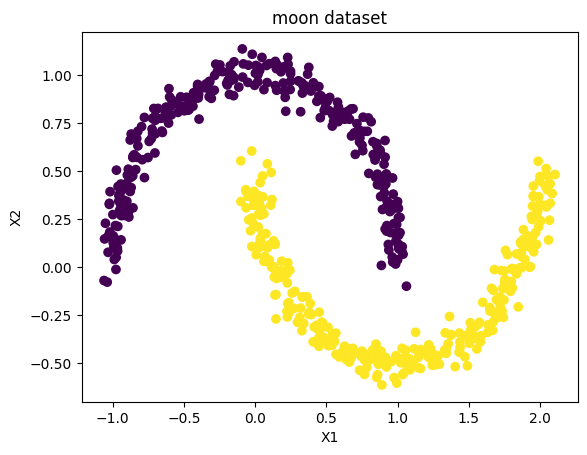

In [ ]:
#visualize on scatter plot
plt.scatter(X[:,0],X[:,1],c=y)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("moon dataset")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.8,random_state=42)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
model=Sequential([
    Dense(16,activation='sigmoid',input_shape=(2,)),
    Dense(32,activation='sigmoid'),
    Dense(24,activation='sigmoid'),
    Dense(8,activation='sigmoid'),
    Dense(1,activation='sigmoid'),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.get_weights()[0]

array([[-4.1657647e-01,  3.3962691e-01, -2.3256123e-02,  2.0210600e-01,
        -4.2462823e-01,  2.4341768e-01,  2.1567011e-01,  4.7962308e-02,
         5.2765298e-01,  3.5056758e-01,  3.1410313e-01,  5.0811291e-02,
        -4.6939799e-01, -4.7864360e-01,  3.2564008e-01,  5.1162446e-01],
       [-1.1937207e-01, -4.6862921e-01,  4.0966272e-04,  5.6775665e-01,
        -1.1544928e-01,  6.0993433e-02, -3.1637409e-01,  6.3959718e-02,
         2.6763666e-01, -3.5087040e-01,  3.6225224e-01,  5.1410246e-01,
        -1.5920511e-01,  5.5927896e-01, -1.3887364e-01,  3.5676533e-01]],
      dtype=float32)

In [ ]:
old_weight = model.get_weights()[0]

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(X_train,y_train,batch_size=60,epochs=10,validation_data=(X_test,y_test))

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.4823 - loss: 0.7009 - val_accuracy: 0.5083 - val_loss: 0.6928
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5161 - loss: 0.6922 - val_accuracy: 0.5083 - val_loss: 0.6923
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5328 - loss: 0.6923 - val_accuracy: 0.4917 - val_loss: 0.6922
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5022 - loss: 0.6921 - val_accuracy: 0.4917 - val_loss: 0.6920
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4970 - loss: 0.6919 - val_accuracy: 0.4917 - val_loss: 0.6916
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5112 - loss: 0.6912 - val_accuracy: 0.4917 - val_loss: 0.6912
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5118 - loss: 0.6907 - val_accuracy: 0.4917 - val_loss: 0.6908
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5092 - loss: 0.6911 - val_accuracy: 0.7833 - val_loss: 0.6901


In [ ]:
print(X_train.shape)
print(y_train.shape)

(480, 2)
(480,)


In [ ]:
model.get_weights()[0]

array([[-0.36606234,  0.39754367, -0.01785213,  0.26373196, -0.5161196 ,
         0.16791773,  0.18775263, -0.03813939,  0.4792774 ,  0.450848  ,
         0.39891705, -0.04173143, -0.5577023 , -0.5716568 ,  0.42373243,
         0.4414496 ],
       [-0.17039324, -0.5283809 , -0.00601215,  0.5083771 , -0.02335807,
         0.13344572, -0.2901911 ,  0.14896926,  0.31146407, -0.45343915,
         0.27758744,  0.6067367 , -0.07051586,  0.653924  , -0.23820493,
         0.42382506]], dtype=float32)

In [ ]:
model_2=Sequential(
    [Dense(16,activation='relu',input_shape=(2,)),
     Dense(32,activation='relu'),
     Dense(24,activation='relu'),
     Dense(8,activation='relu'),
     Dense(1,activation='sigmoid')
     ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
new_weights=model_2.get_weights()[0]

In [ ]:
model_2.fit(X_train,y_train,batch_size=60,epochs=10,validation_data=(X_test,y_test))

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.5052 - loss: 0.7208 - val_accuracy: 0.5500 - val_loss: 0.6954
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5934 - loss: 0.6867 - val_accuracy: 0.6417 - val_loss: 0.6752
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7362 - loss: 0.6698 - val_accuracy: 0.8333 - val_loss: 0.6589
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8563 - loss: 0.6527 - val_accuracy: 0.8417 - val_loss: 0.6408
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8746 - loss: 0.6322 - val_accuracy: 0.8500 - val_loss: 0.6190
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8551 - loss: 0.6122 - val_accuracy: 0.8500 - val_loss: 0.5922
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8657 - loss: 0.5744 - val_accuracy: 0.8500 - val_loss: 0.5586
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8567 - loss: 0.5392 - val_accuracy: 0.8500 - val_loss: 0.5204


16/03/2026
Data Preprocessing

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf


In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/Pranjali1049/Salary_Prediction/refs/heads/main/Salary_Data.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [ ]:
df.isnull().sum()

,0
Age,2
Gender,2
Education Level,3
Job Title,2
Years of Experience,3
Salary,5


In [ ]:
df['Age'].fillna(df['Age'].mean(),inplace=True)


In [ ]:
df['Gender'].fillna(df['Gender'].mode()[0],inplace=True)
df['Education Level'].fillna(df['Education Level'].mode()[0],inplace=True)
df['Job Title'].fillna(df['Job Title'].mode()[0],inplace=true)
df

/tmp/ipykernel_336/920239111.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0],inplace=True)
/tmp/ipykernel_336/920239111.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

NameError: name 'true' is not defined

30/03/26

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers , models
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
model= models.Sequential()
model.add(Dense(128,activation='relu',input_shape=(784,)))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'],
             )

In [ ]:
from re import VERBOSE
# Applying Easy Stopping
from tensorflow.keras.callbacks import EarlyStopping
# parameter
callback = EarlyStopping(monitor = 'val_loss',
                         min_delta= 0.0001,
                         patience = 20,
                         verbose=1,
                         mode='auto',
                         baseline= None,
                         restore_best_weights= False)

In [ ]:
(X_test,y_test),(X_train,y_train)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#print both shape for train and test
print("Train shape",X_train.shape)
print("test shape",X_test.shape)

Train shape (10000, 28, 28)
test shape (60000, 28, 28)


In [ ]:
#normalisation the data (by 255 pixels)
X_train=X_train/ 255.0
X_test=X_test/ 255.0

In [ ]:
#one-hot encoding
from tensorflow.keras.utils import to_categorical
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)


01/04/2026
Build a neural network

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [ ]:
# normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
#Method 2
model = models.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',   # ✅ IMPORTANT
    metrics=['accuracy']
)

In [ ]:
# early stopping
callback = EarlyStopping(
    monitor='val_loss',
    patience=4
)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    callbacks=[callback]
)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9946 - loss: 0.0173 - val_accuracy: 0.9801 - val_loss: 0.0878
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9950 - loss: 0.0168 - val_accuracy: 0.9803 - val_loss: 0.0975
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9952 - loss: 0.0150 - val_accuracy: 0.9751 - val_loss: 0.1126
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9952 - loss: 0.0155 - val_accuracy: 0.9789 - val_loss: 0.1154


<function matplotlib.pyplot.show(close=None, block=None)>

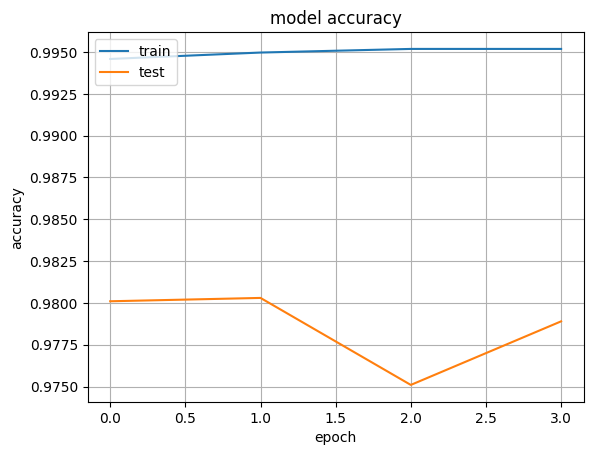

In [ ]:
#visulaization
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.grid(True)
plt.legend(['train', 'test'], loc='upper left')
plt.show

02/04/2026

In [ ]:
! pip install keras-tuner


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import kerastuner as kt
from tensorflow.keras import layers,models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import EarlyStopping
from kerastuner.tuners import RandomSearch

/tmp/ipykernel_3696/1746786811.py:4: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  import kerastuner as kt


In [ ]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()

In [ ]:
X_train=X_train/255.0
X_test=X_test/255.0

In [ ]:
def build_model(hp):
  model=keras.Sequential()
  model.add(layers.Flatten(input_shape=(28,28)))
  for i in range(hp.Int('num_layers',1,5)):
    model.add(layers.Dense(units=hp.Int(f'units_{i} , min_value=32,max_value=256,steps=32'),
                           activation='relu'))
    model.add(Dropout(0.2))
    model.add(BatchNormalization())
  model.add(layers.Dense(10,activation='softmax'))

  model.compile(optimizer=keras.optimizers.Adam(
      hp.Choice('learning_rate',values=[0.001,0.0005])
  ))

  return model